# 01 EDA v2 — Polymarket Prediction Markets

Exploratory data analysis for the binary classification task:
**Predict whether a market will reach high liquidity (volume >= 75th percentile).**

This notebook reads the processed feature matrix from `data/features.parquet` instead of the raw CSVs, following the project rule of avoiding direct reads of large CSV files.

In [1]:
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings('ignore')

# Logging configuration: no print() statements, use logging instead
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Plotting defaults
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

In [2]:
# Load processed feature matrix derived from polymarket_markets.csv and polymarket_events.csv
DATA_PATH = 'data/features.parquet'
df = pd.read_parquet(DATA_PATH)

logger.info('Dataset shape: %s', df.shape)
logger.info('Columns (%d): %s', len(df.columns), df.columns.tolist())
logger.info('Missing values per column:\n%s', df.isnull().sum().to_string())

2026-06-13 20:37:43,547 - INFO - Dataset shape: (94204, 23)


2026-06-13 20:37:43,548 - INFO - Columns (23): ['high_liquidity', 'duration_days', 'created_hour', 'created_dow', 'created_month', 'spread_initial', 'has_orderbook', 'is_featured', 'is_accepting_orders', 'is_negrisk', 'event_market_count', 'event_total_volume', 'tag_category', 'tag_Basketball', 'tag_Crypto', 'tag_Crypto Prices', 'tag_Esports', 'tag_Games', 'tag_Politics', 'tag_Sports', 'tag_Tennis', 'tag_Up or Down', 'tag_other']


2026-06-13 20:37:43,551 - INFO - Missing values per column:
high_liquidity         0
duration_days          0
created_hour           0
created_dow            0
created_month          0
spread_initial         0
has_orderbook          0
is_featured            0
is_accepting_orders    0
is_negrisk             0
event_market_count     0
event_total_volume     0
tag_category           0
tag_Basketball         0
tag_Crypto             0
tag_Crypto Prices      0
tag_Esports            0
tag_Games              0
tag_Politics           0
tag_Sports             0
tag_Tennis             0
tag_Up or Down         0
tag_other              0


## 1. Dataset overview

The feature matrix contains engineered variables from both raw tables. `high_liquidity` is the binary target (1 = volume in top quartile).

In [3]:
# Separate feature groups for cleaner analysis
target = 'high_liquidity'
numeric_features = [
    'duration_days', 'created_hour', 'created_dow', 'created_month',
    'spread_initial', 'event_market_count', 'event_total_volume'
]
binary_features = [
    'has_orderbook', 'is_featured', 'is_accepting_orders', 'is_negrisk'
]
tag_features = [c for c in df.columns if c.startswith('tag_') and c != 'tag_category']

logger.info('Numeric features: %s', numeric_features)
logger.info('Binary features: %s', binary_features)
logger.info('Tag dummies: %s', tag_features)

df[numeric_features + binary_features].describe().round(3)

2026-06-13 20:37:43,557 - INFO - Numeric features: ['duration_days', 'created_hour', 'created_dow', 'created_month', 'spread_initial', 'event_market_count', 'event_total_volume']


2026-06-13 20:37:43,558 - INFO - Binary features: ['has_orderbook', 'is_featured', 'is_accepting_orders', 'is_negrisk']


2026-06-13 20:37:43,559 - INFO - Tag dummies: ['tag_Basketball', 'tag_Crypto', 'tag_Crypto Prices', 'tag_Esports', 'tag_Games', 'tag_Politics', 'tag_Sports', 'tag_Tennis', 'tag_Up or Down', 'tag_other']


,duration_days,created_hour,created_dow,created_month,spread_initial,event_market_count,event_total_volume,has_orderbook,is_featured,is_accepting_orders,is_negrisk
count,94204.000,94204.000,94204.000,94204.000,94204.000,94204.000,9.420400e+04,94204.000,94204.000,94204.000,94204.000
mean,42.235,14.214,2.502,10.202,0.195,12.915,2.124144e+06,0.983,0.000,0.258,0.287
std,115.093,6.474,2.002,1.836,0.363,20.427,1.985936e+07,0.129,0.022,0.438,0.452
min,0.000,0.000,0.000,1.000,0.001,1.000,0.000000e+00,0.000,0.000,0.000,0.000
25%,1.000,10.000,1.000,10.000,0.001,1.000,3.256040e+03,1.000,0.000,0.000,0.000
50%,4.000,16.000,2.000,11.000,0.010,5.000,2.976061e+04,1.000,0.000,0.000,0.000
75%,13.000,19.000,4.000,11.000,0.080,15.000,2.170161e+05,1.000,0.000,1.000,1.000
max,1214.000,23.000,6.000,12.000,1.000,139.000,6.086758e+08,1.000,1.000,1.000,1.000


## 2. Target distribution

High-liquidity markets are the minority class (~24%). This class imbalance must be handled in modeling (stratified sampling, class weights, or resampling).

In [4]:
# Class counts and proportions
target_counts = df[target].value_counts().reset_index()
target_counts.columns = [target, 'count']
target_counts['proportion'] = target_counts['count'] / target_counts['count'].sum()
logger.info('Target distribution:\n%s', target_counts.to_string(index=False))

fig = px.pie(
    target_counts,
    names=target,
    values='count',
    title='Target distribution: high_liquidity',
    color=target,
    color_discrete_map={0: '#EF553B', 1: '#00cc96'}
)
fig.update_traces(textinfo='label+percent', pull=[0, 0.05])
fig.show()

2026-06-13 20:37:43,610 - INFO - Target distribution:
 high_liquidity  count  proportion
              0  71522    0.759225
              1  22682    0.240775


## 3. Univariate analysis of numeric features

Volume-related features are extremely right-skewed, so log transformations are useful for visualization. Spread is bounded between 0 and 1.

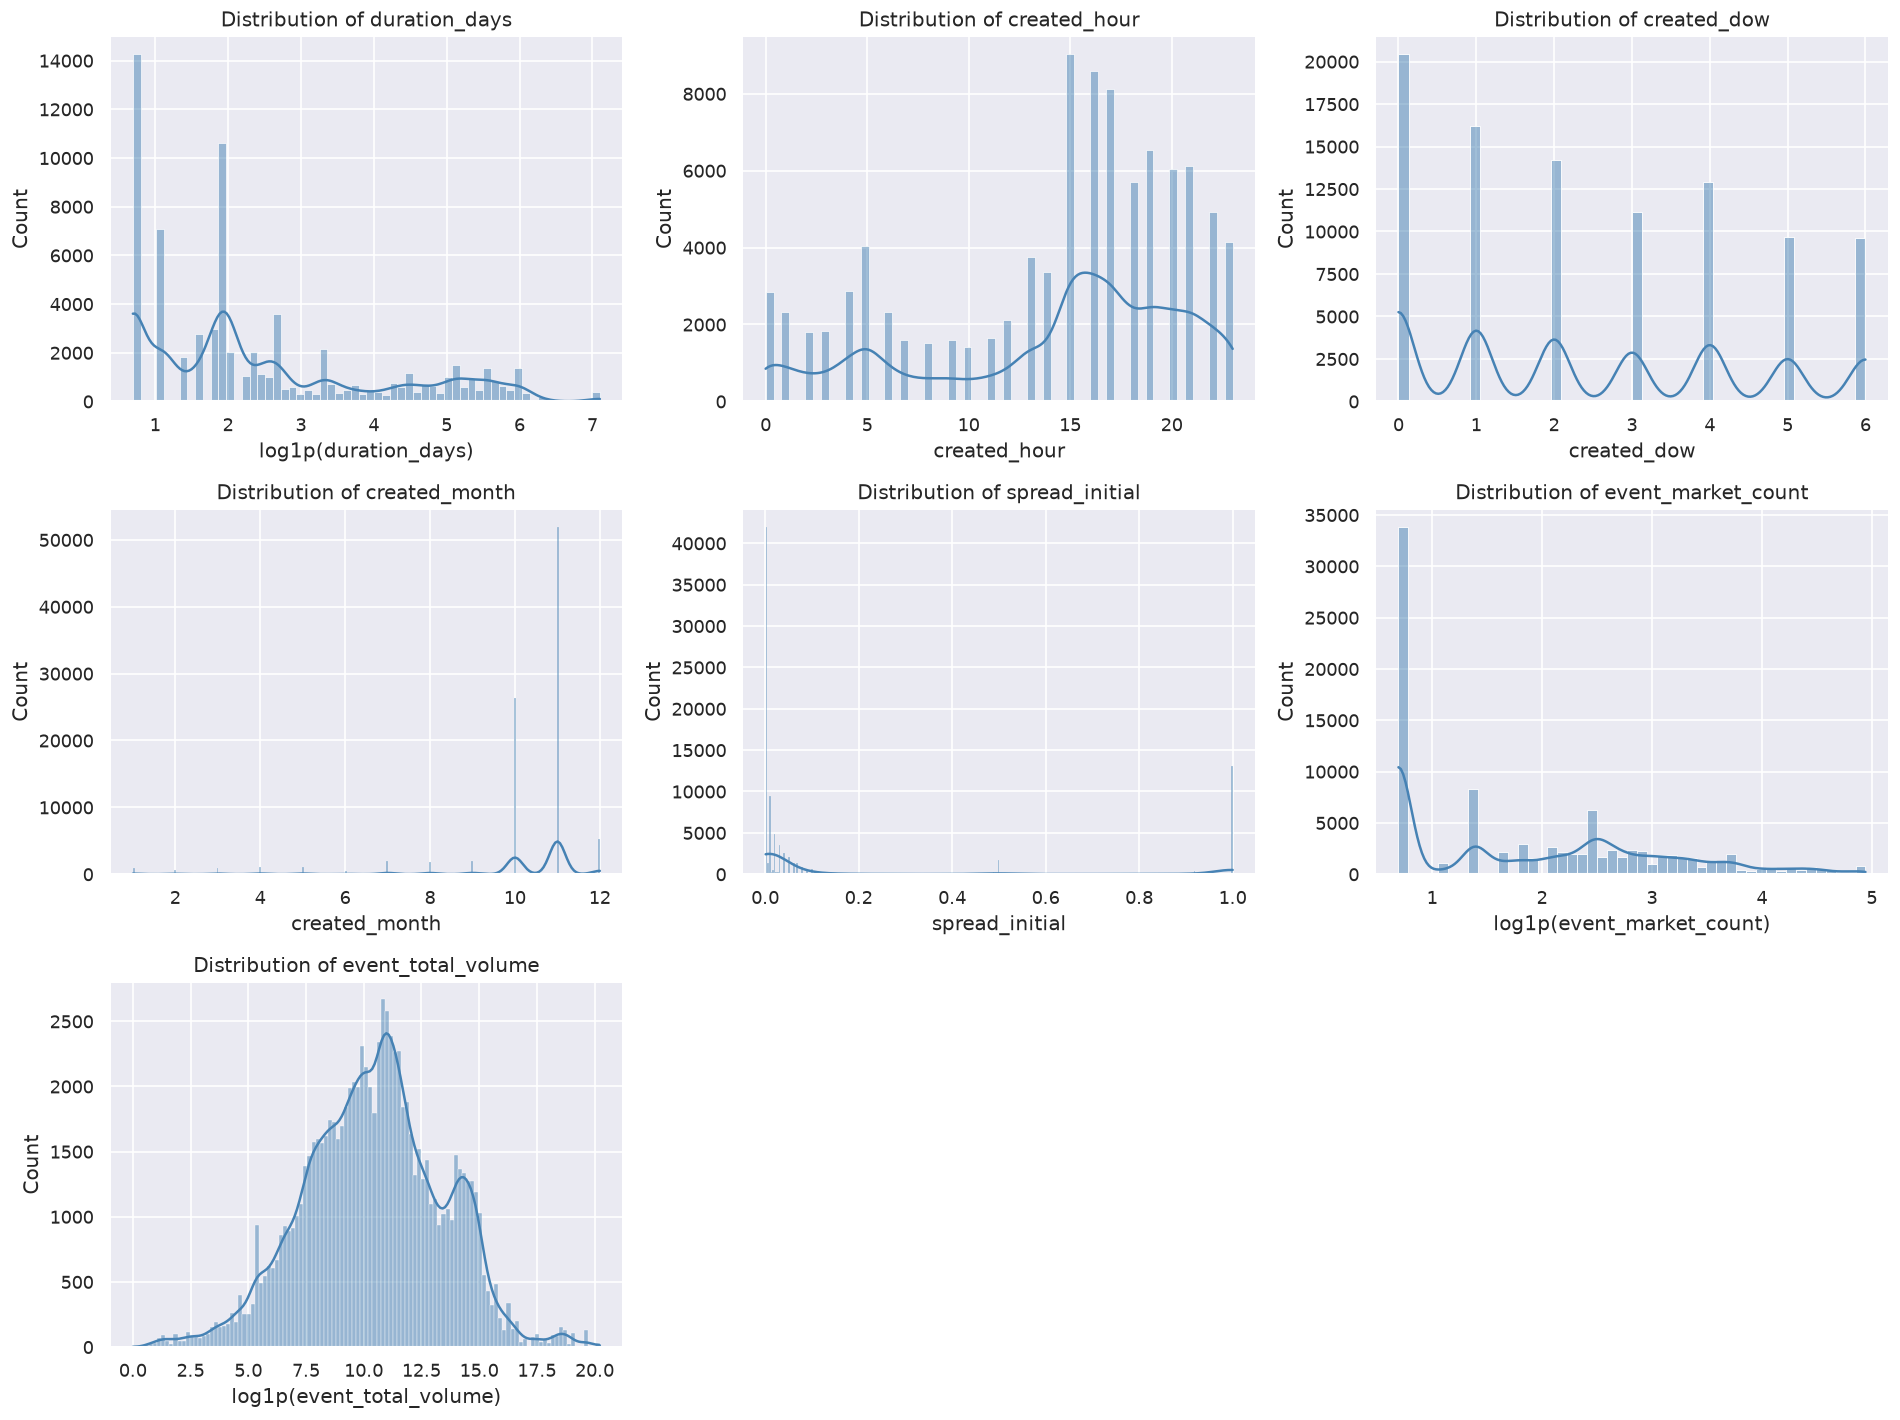

In [5]:
# Histograms for numeric features (log scale for heavy-tailed variables)
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_features):
    # Use log scale for heavy-tailed positive variables; keep raw scale for cyclic temporal features
    if col in ['event_total_volume', 'event_market_count', 'duration_days']:
        data = df[col].replace(0, np.nan).dropna()
        sns.histplot(np.log1p(data), kde=True, ax=axes[idx], color='steelblue')
        axes[idx].set_xlabel(f'log1p({col})')
    else:
        sns.histplot(df[col], kde=True, ax=axes[idx], color='steelblue')
        axes[idx].set_xlabel(col)
    axes[idx].set_title(f'Distribution of {col}')

# Hide unused subplots
for idx in range(len(numeric_features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Category/tag analysis

Sports and 'Up or Down' tags dominate the dataset. The high-liquidity rate varies strongly by tag, which makes tag dummies valuable predictors.

In [6]:
# Tag frequencies and liquidity rates
tag_summary = (
    df.groupby('tag_category')
    .agg(
        market_count=(target, 'size'),
        high_liquidity_rate=(target, 'mean')
    )
    .reset_index()
    .sort_values('market_count', ascending=False)
)
logger.info('Tag category summary:\n%s', tag_summary.to_string(index=False))

fig = px.bar(
    tag_summary,
    x='tag_category',
    y='market_count',
    color='high_liquidity_rate',
    color_continuous_scale='Teal',
    title='Market count and high-liquidity rate by tag category',
    text='high_liquidity_rate',
    labels={'high_liquidity_rate': 'high liquidity rate'}
)
fig.update_traces(texttemplate='%{text:.2%}', textposition='outside')
fig.show()

2026-06-13 20:37:47,706 - INFO - Tag category summary:
 tag_category  market_count  high_liquidity_rate
        other         32824             0.229923
       Sports         28429             0.167716
   Up or Down         17851             0.280320
       Crypto          6037             0.575286
     Politics          3014             0.150630
      Esports          2633             0.238891
        Games          1360             0.178676
       Tennis           867             0.423299
   Basketball           718             0.032033
Crypto Prices           471             0.369427


## 5. Temporal patterns

Market creation time may capture platform activity cycles and editorial scheduling.

2026-06-13 20:37:47,777 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-13 20:37:47,784 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-13 20:37:47,953 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-13 20:37:47,962 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-13 20:37:48,025 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-13 20:37:48,032 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


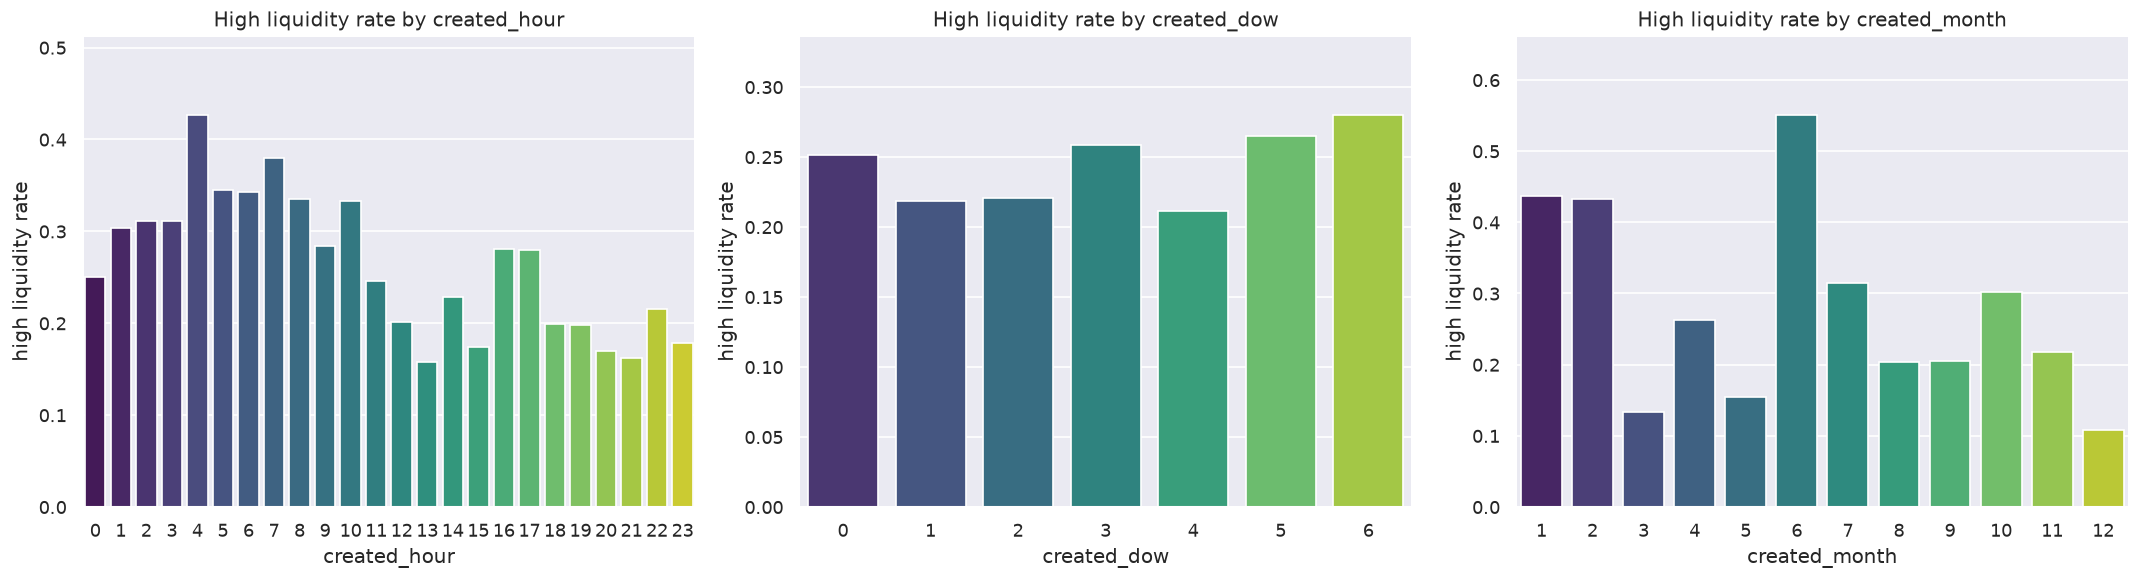

In [7]:
# High-liquidity rate by hour, day-of-week and month of creation
temporal_features = ['created_hour', 'created_dow', 'created_month']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, temporal_features):
    rate_by_temp = df.groupby(col)[target].mean().reset_index()
    sns.barplot(data=rate_by_temp, x=col, y=target, ax=ax, palette='viridis')
    ax.set_ylabel('high liquidity rate')
    ax.set_title(f'High liquidity rate by {col}')
    ax.set_ylim(0, rate_by_temp[target].max() * 1.2)

plt.tight_layout()
plt.show()

## 6. Bivariate analysis

Correlation and conditional distributions reveal which features are most discriminative for liquidity.

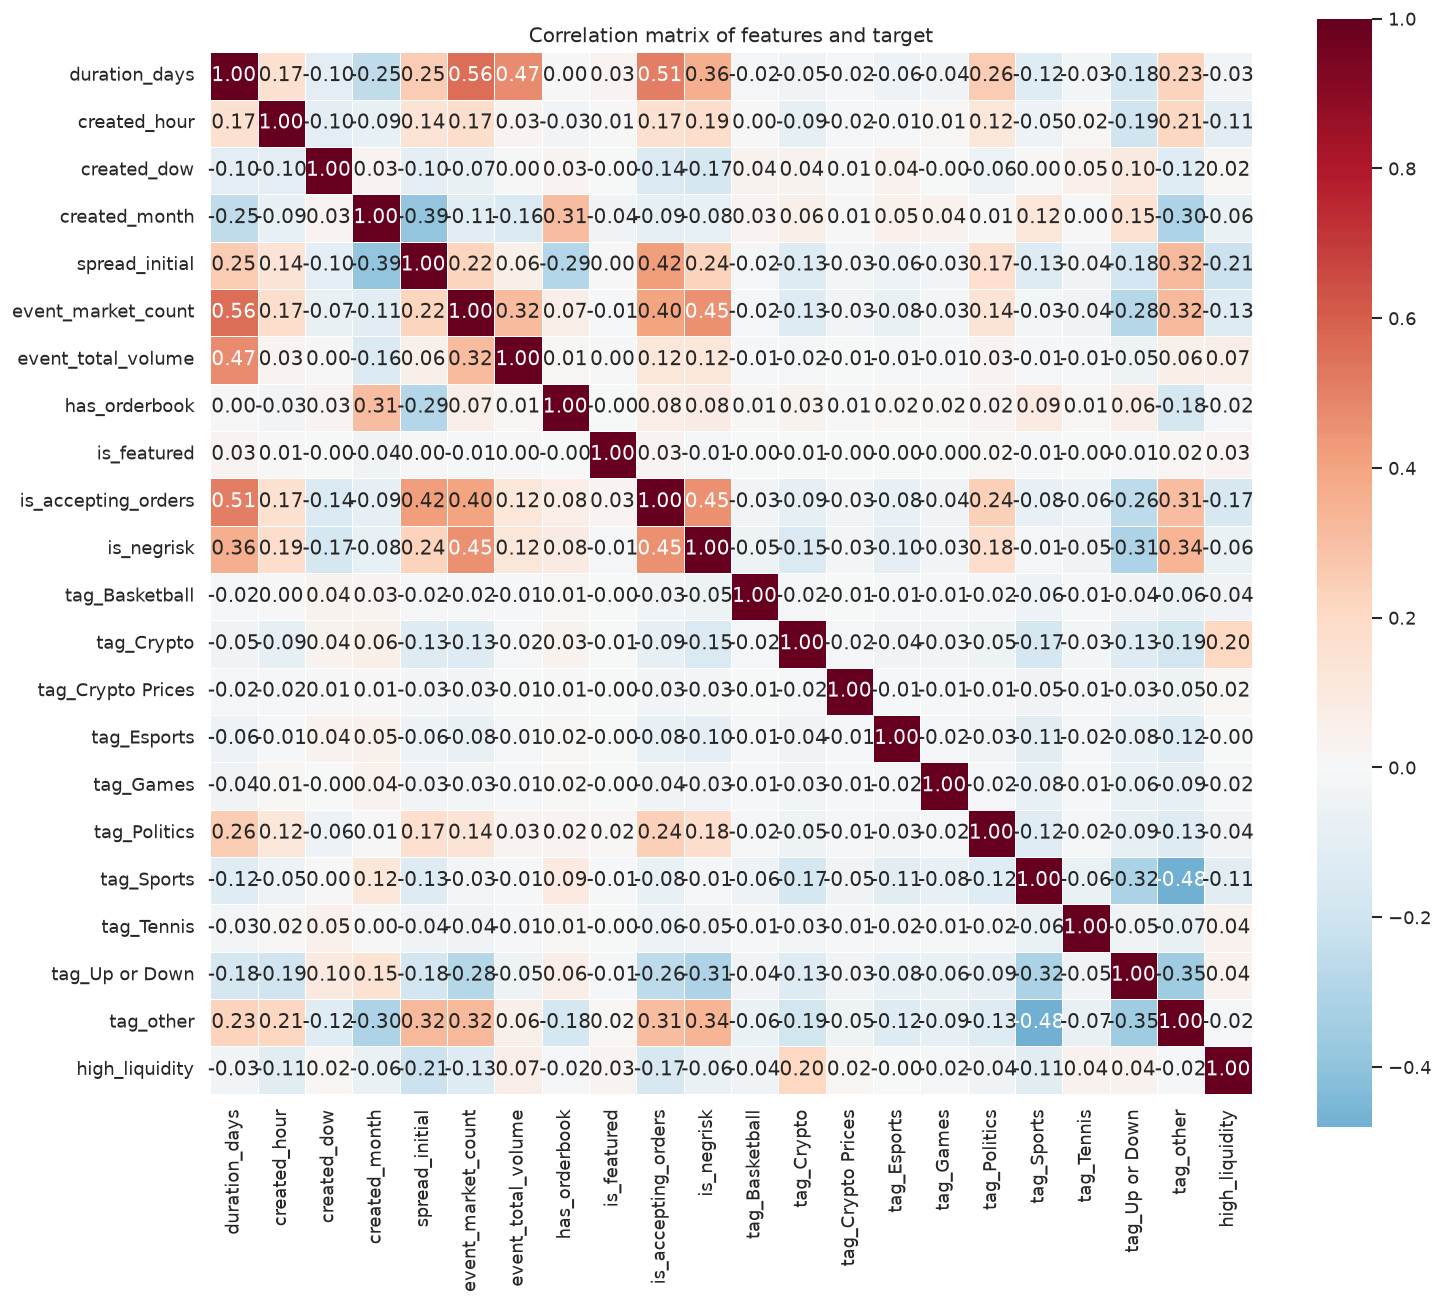

In [8]:
# Correlation matrix of numeric and binary features with the target
corr_cols = numeric_features + binary_features + tag_features + [target]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation matrix of features and target')
plt.show()

In [9]:
# Liquidity rate across spread bins
df['spread_bin'] = pd.cut(df['spread_initial'], bins=10, precision=2)
spread_liq = df.groupby('spread_bin')[target].agg(['mean', 'count']).reset_index()
spread_liq['spread_bin_mid'] = spread_liq['spread_bin'].apply(lambda x: x.mid)

fig = px.bar(
    spread_liq,
    x='spread_bin_mid',
    y='mean',
    title='High-liquidity rate by initial spread bin',
    labels={'mean': 'high liquidity rate', 'spread_bin_mid': 'initial spread'},
    text='count'
)
fig.update_traces(texttemplate='n=%{text}', textposition='outside')
fig.show()

In [10]:
# Relationship between event size (number of markets) and high-liquidity rate
df['event_size_bin'] = pd.cut(
    df['event_market_count'],
    bins=[0, 1, 5, 15, 50, 200],
    labels=['1', '2-5', '6-15', '16-50', '50+']
)
size_liq = df.groupby('event_size_bin')[target].agg(['mean', 'count']).reset_index()

fig = px.bar(
    size_liq,
    x='event_size_bin',
    y='mean',
    title='High-liquidity rate by number of markets in parent event',
    labels={'mean': 'high liquidity rate', 'event_size_bin': 'markets per event'},
    text='count'
)
fig.update_traces(texttemplate='n=%{text}', textposition='outside')
fig.show()

In [11]:
# Relationship between total event volume and market liquidity
df['log_event_volume'] = np.log1p(df['event_total_volume'])
df['event_volume_decile'] = pd.qcut(df['event_total_volume'].rank(method='first'), q=10, labels=False) + 1
vol_liq = df.groupby('event_volume_decile')[target].agg(['mean', 'count']).reset_index()

fig = px.bar(
    vol_liq,
    x='event_volume_decile',
    y='mean',
    title='High-liquidity rate by parent event volume decile',
    labels={'mean': 'high liquidity rate', 'event_volume_decile': 'event volume decile'},
    text='count'
)
fig.update_traces(texttemplate='n=%{text}', textposition='outside')
fig.show()

2026-06-13 20:37:50,121 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-13 20:37:50,150 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-13 20:37:50,225 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-13 20:37:50,254 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-13 20:37:50,339 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-13 20:37:50,367 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-13 20:37:50,473 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-13 20:37:50,502 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


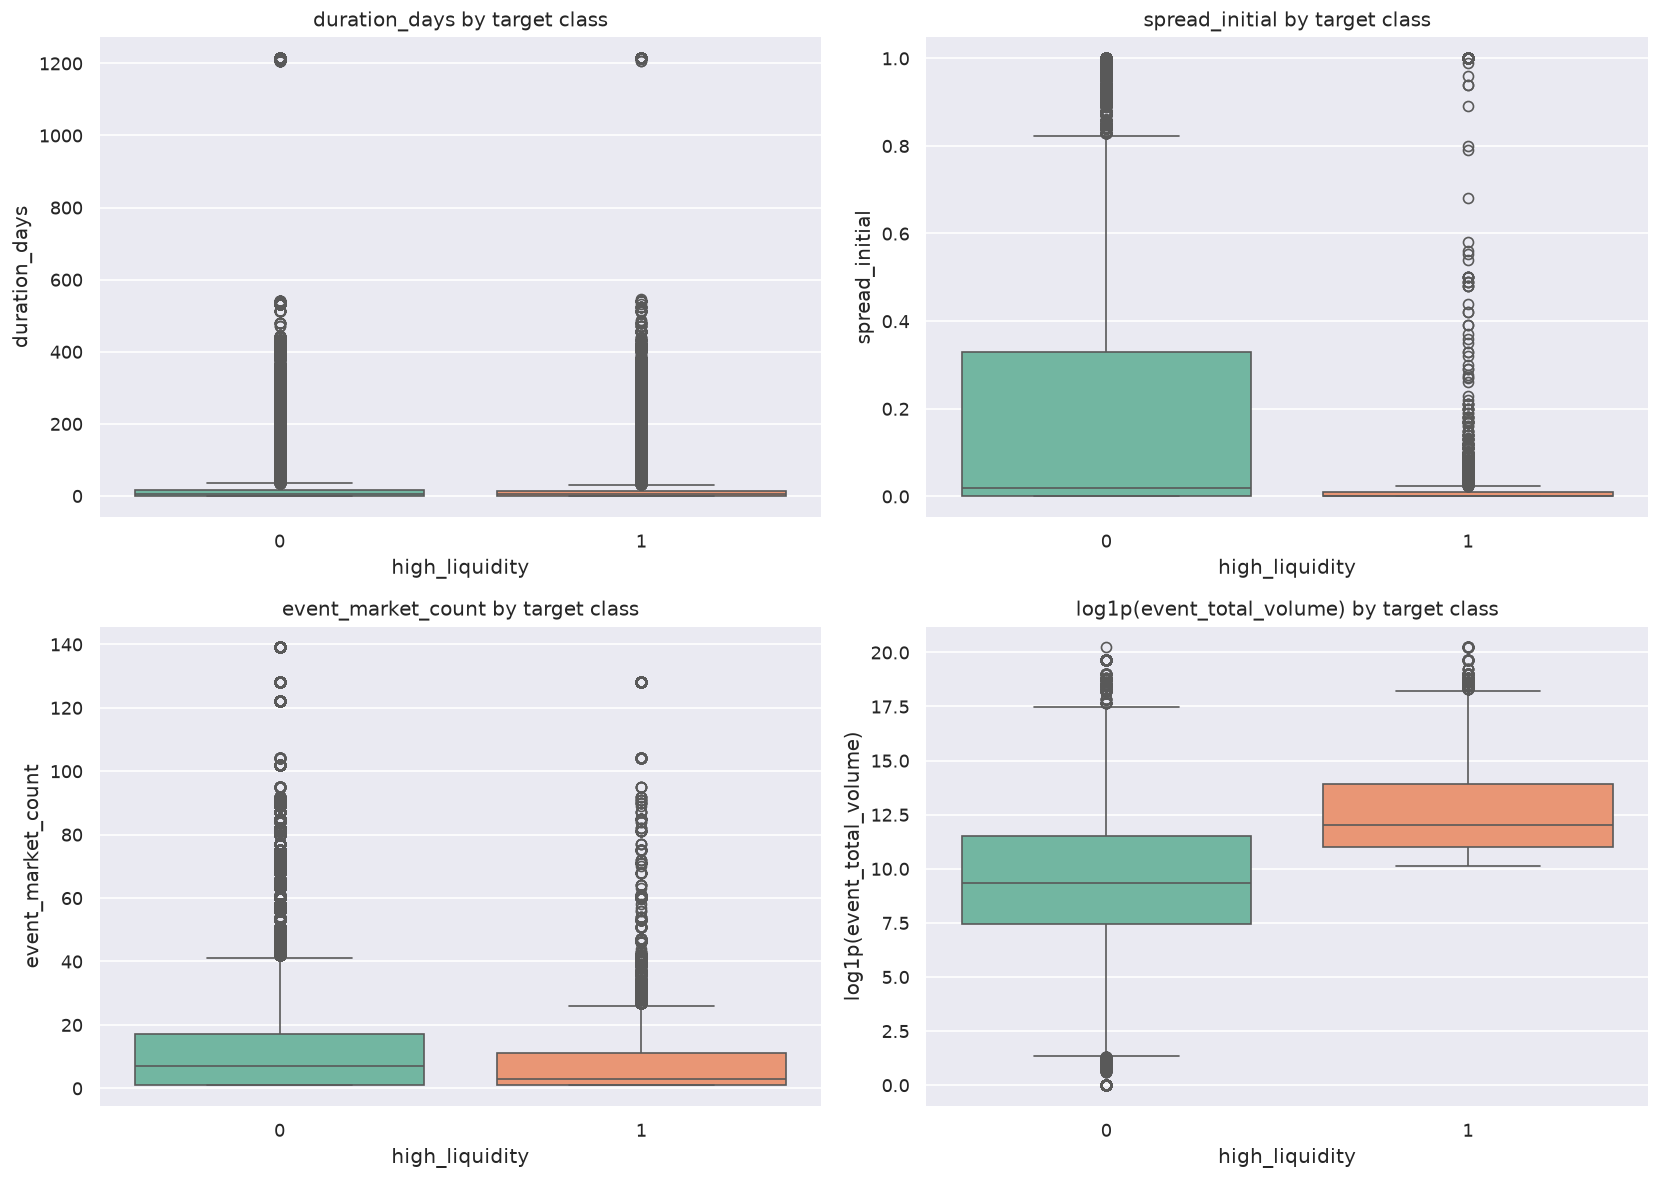

In [12]:
# Boxplots of key numeric features split by target class
plot_features = ['duration_days', 'spread_initial', 'event_market_count', 'event_total_volume']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(plot_features):
    if col == 'event_total_volume':
        plot_data = df.copy()
        plot_data[col] = np.log1p(plot_data[col])
        ylabel = f'log1p({col})'
    else:
        plot_data = df
        ylabel = col
    sns.boxplot(data=plot_data, x=target, y=col, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{ylabel} by target class')
    axes[idx].set_ylabel(ylabel)

plt.tight_layout()
plt.show()

## 7. Outlier detection

Extreme values in `event_total_volume` and `event_market_count` can distort models. IQR-based flags are created for review.

In [13]:
# IQR-based outlier flags for heavy-tailed numeric features
outlier_cols = ['duration_days', 'event_market_count', 'event_total_volume']
outlier_summary = []

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flag_col = f'{col}_outlier'
    df[flag_col] = ((df[col] < lower) | (df[col] > upper)).astype(int)
    outlier_summary.append({
        'feature': col,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': df[flag_col].sum(),
        'outlier_pct': df[flag_col].mean() * 100
    })

outlier_df = pd.DataFrame(outlier_summary)
logger.info('IQR outlier summary:\n%s', outlier_df.to_string(index=False))
outlier_df

2026-06-13 20:37:50,998 - INFO - IQR outlier summary:
           feature    lower_bound   upper_bound  outlier_count  outlier_pct
     duration_days     -17.000000     31.000000          17465    18.539552
event_market_count     -20.000000     36.000000           8698     9.233154
event_total_volume -317383.982986 537656.079377          16870    17.907944


,feature,lower_bound,upper_bound,outlier_count,outlier_pct
0,duration_days,-17.000000,31.000000,17465,18.539552
1,event_market_count,-20.000000,36.000000,8698,9.233154
2,event_total_volume,-317383.982986,537656.079377,16870,17.907944


## 8. Feature-target associations

Mutual information estimates how much each feature reduces uncertainty about the target. Point-biserial correlation is reported for numeric features.

In [14]:
# Mutual information between features and target
feature_cols = numeric_features + binary_features + tag_features
X = df[feature_cols]
y = df[target]

mi_scores = mutual_info_classif(X, y, random_state=42, discrete_features='auto')
mi_df = pd.DataFrame({'feature': feature_cols, 'mutual_info': mi_scores})
mi_df = mi_df.sort_values('mutual_info', ascending=False)
logger.info('Top features by mutual information:\n%s', mi_df.head(15).to_string(index=False))

fig = px.bar(
    mi_df.head(15),
    x='mutual_info',
    y='feature',
    orientation='h',
    title='Top 15 features by mutual information with high_liquidity',
    color='mutual_info',
    color_continuous_scale='Blues'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

2026-06-13 20:37:57,469 - INFO - Top features by mutual information:
            feature  mutual_info
 event_total_volume     0.324577
     spread_initial     0.057364
      duration_days     0.049744
 event_market_count     0.029246
is_accepting_orders     0.017878
       created_hour     0.016390
      created_month     0.016316
         tag_Crypto     0.015943
         tag_Sports     0.010902
      has_orderbook     0.008613
         is_negrisk     0.005494
          tag_other     0.004930
     tag_Up or Down     0.004466
       tag_Politics     0.001290
        tag_Esports     0.000607


In [15]:
# Point-biserial correlation for numeric features
pb_corr = []
for col in numeric_features:
    r, p = stats.pointbiserialr(df[target], df[col])
    pb_corr.append({'feature': col, 'correlation': r, 'p_value': p})

pb_df = pd.DataFrame(pb_corr).sort_values('correlation', key=abs, ascending=False)
logger.info('Point-biserial correlations with target:\n%s', pb_df.to_string(index=False))
pb_df

2026-06-13 20:37:57,549 - INFO - Point-biserial correlations with target:
           feature  correlation       p_value
    spread_initial    -0.212721  0.000000e+00
event_market_count    -0.125443  0.000000e+00
      created_hour    -0.113751 8.844620e-269
event_total_volume     0.067835  1.721995e-96
     created_month    -0.064396  3.992011e-87
     duration_days    -0.033655  5.022956e-25
       created_dow     0.019621  1.716143e-09


,feature,correlation,p_value
4,spread_initial,-0.212721,0.000000e+00
5,event_market_count,-0.125443,0.000000e+00
1,created_hour,-0.113751,8.844620e-269
6,event_total_volume,0.067835,1.721995e-96
3,created_month,-0.064396,3.992011e-87
0,duration_days,-0.033655,5.022956e-25
2,created_dow,0.019621,1.716143e-09


## 9. Conclusions

### What was explored
- The processed feature matrix (`data/features.parquet`) contains 94,204 rows and 23 columns.
- The target `high_liquidity` is imbalanced: roughly 24% of markets belong to the high-liquidity class.
- Numeric features are heavily right-skewed; log transformation improves interpretability.

### What works as a predictor
- **Event-level volume (`event_total_volume`)** is the strongest univariate signal: markets inside high-volume events are far more likely to be liquid.
- **Event size (`event_market_count`)**: larger events (more sibling markets) tend to produce more liquid individual markets.
- **Tag/category dummies**: Sports, Crypto and Politics tags show different base liquidity rates, confirming that thematic demand matters.
- **Initial spread**: very tight or very wide spreads have distinct liquidity patterns; spread captures initial market-making activity.

### What does not work / caveats
- **Temporal features alone** (hour, day-of-week, month) show only weak differences in liquidity rate; they are unlikely to be strong main effects but may help as interaction features.
- **`is_featured`** is almost always zero in this snapshot, so it has little discriminative power here.
- **Outliers** in `event_total_volume` and `event_market_count` are common; tree-based models will handle them naturally, but linear models may need clipping or log transforms.

### Recommended next steps
- Use stratified train/validation splits to preserve the 24/76 class ratio.
- Experiment with log transforms and quantile binning for `event_total_volume` and `event_market_count`.
- Add interaction features such as `log_event_volume × spread` or `tag_category × duration_days`.
- Consider class weights or threshold tuning because the minority class is the business-relevant one.